# Validate the Python world-camera reconstruction pipeline

Load every example world-camera measurement, run both MATLAB `reconstructionPipeline` and Python `world_transformation_pipeline`, and quantify their numerical agreement. The notebook uses one MATLAB Engine session for the complete validation run.

In [1]:
# Import the Python libraries used for paths, numerical calculations, tables, plotting,
# MATLAB-file loading, and communication with MATLAB.
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io
import matlab.engine


# First, define some paths we are going to reuse

PROJECT_ROOT: Path = Path("/Users/zacharykelly/Documents/MATLAB/projects/lightLoggerAnalysis")
CODE_ROOT: Path = PROJECT_ROOT / "code"
EXAMPLE_DATA_DIR: Path = PROJECT_ROOT / "data" / "exampleWorldCameraImages"
SENSOR_UTILITY_DIR: Path = CODE_ROOT / "library" / "sensor_utility"

# Add our sensor utility folder to Python's module search path so world_util can be imported.
sys.path.append(str(SENSOR_UTILITY_DIR))
import world_util

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/zacharykelly/Documents/MATLAB/projects/lightLoggerAnalysis


In [2]:
# Next, let's load in the measurements
# glob finds every example MAT file whose name contains _AGCandMS_. Sorting the
# paths makes the processing and output order reproducible.
measurement_paths: list[Path] = sorted(EXAMPLE_DATA_DIR.glob("*_AGCandMS_*.mat"))
if not measurement_paths:
    raise FileNotFoundError(f"No example measurements found in {EXAMPLE_DATA_DIR}")

print(f"Found {len(measurement_paths)} measurements:")
for measurement_path in measurement_paths:
    print(f"  {measurement_path.name}")

Found 6 measurements:
  indoor_AGCandMS_01.mat
  indoor_AGCandMS_02.mat
  indoor_AGCandMS_03.mat
  outdoor_AGCandMS_01.mat
  outdoor_AGCandMS_02.mat
  planetarium_AGCandMS_01.mat


In [3]:
def compare_pipeline_results(
    measurement_name: str,
    matlab_radiance: np.ndarray,
    python_radiance: np.ndarray,
) -> tuple[dict[str, object], np.ndarray]:
    """Calculate finite-value errors and compare non-finite masks."""

    # If the shape is not equal, this is a huge serious error 
    if matlab_radiance.shape != python_radiance.shape:
        raise ValueError(
            f"Shape mismatch for {measurement_name}: MATLAB {matlab_radiance.shape}, "
            f"Python {python_radiance.shape}."
        )

    # Find the finite pixels in both images
    finite_in_both: np.ndarray = np.isfinite(matlab_radiance) & np.isfinite(python_radiance)

    # Allocate an array for the absolute error between the images
    absolute_error: np.ndarray = np.full(matlab_radiance.shape, np.nan, dtype=np.float64)

    # Find the absolute error of the finite pixels
    absolute_error[finite_in_both] = np.abs(
        python_radiance[finite_in_both] - matlab_radiance[finite_in_both]
    )

    # Relative error requires division by the MATLAB result. Exclude zero-valued
    # MATLAB pixels so that this calculation does not divide by zero.
    relative_denominator: np.ndarray = finite_in_both & (matlab_radiance != 0)
    relative_error: np.ndarray = absolute_error[relative_denominator] / np.abs(
        matlab_radiance[relative_denominator]
    )
    # Pull the valid absolute errors into a one-dimensional vector so summary
    # statistics can be calculated without the NaNs used in the error image.
    finite_absolute_error: np.ndarray = absolute_error[finite_in_both]

    # Record several complementary comparisons. RMSE emphasizes larger errors;
    # the mask checks verify that MATLAB and Python mark the same pixels as Inf
    # or NaN; allclose performs the final tolerance-based array comparison.
    metrics: dict[str, object] = {
        "measurement": measurement_name,
        "finite_pixels": int(np.count_nonzero(finite_in_both)),
        "max_absolute_error": float(np.max(finite_absolute_error)),
        "mean_absolute_error": float(np.mean(finite_absolute_error)),
        "rmse": float(np.sqrt(np.mean(finite_absolute_error ** 2))),
        "max_relative_error": float(np.max(relative_error)) if relative_error.size else 0.0,
        "inf_masks_equal": bool(np.array_equal(np.isinf(matlab_radiance), np.isinf(python_radiance))),
        "nan_masks_equal": bool(np.array_equal(np.isnan(matlab_radiance), np.isnan(python_radiance))),
        "allclose": bool(np.allclose(matlab_radiance, python_radiance, rtol=1e-12, atol=1e-12, equal_nan=True)),
    }
    return metrics, absolute_error

In [4]:
# Store one metrics row and the image outputs for every measurement.
comparison_rows: list[dict[str, object]] = []
comparison_outputs: dict[str, dict[str, np.ndarray]] = {}

# Start MATLAB only once. tbUseProject activates lightLoggerAnalysis and adds
# the project plus its configured toolbox dependencies to the MATLAB path.
matlab_engine: object = matlab.engine.start_matlab()
matlab_engine.tbUseProject("lightLoggerAnalysis", nargout=0)

try:
    for measurement_path in measurement_paths:
        # Load the same three variables used by demoProcessingStages.m.
        # variable_names prevents scipy from loading unrelated variables from the file.
        # simplify_cells=True converts MATLAB structs/cells into simpler Python dict/list
        # objects and removes singleton dimensions. In particular, AGCSettings becomes
        # a normal dictionary instead of a nested one-element structured NumPy array.
        python_data: dict[str, object] = scipy.io.loadmat(
            measurement_path,
            variable_names=["worldFrame", "AGCSettings", "minispectValue"],
            simplify_cells=True,
        )
        # Convert the raw world frame explicitly to a NumPy array. Extract each AGC
        # setting from the simplified MATLAB struct and convert it to a Python float.
        world_frame: np.ndarray = np.asarray(python_data["worldFrame"])
        matlab_agc_settings: dict[str, object] = python_data["AGCSettings"]
        agc_settings: dict[str, float] = {
            "exposure": float(np.asarray(matlab_agc_settings["exposure"]).squeeze()),
            "Again": float(np.asarray(matlab_agc_settings["Again"]).squeeze()),
            "Dgain": float(np.asarray(matlab_agc_settings["Dgain"]).squeeze()),
        }
        # This pipeline comparison does not consume minispectValue, but loading it here
        # keeps the notebook's input behavior aligned with demoProcessingStages.m.
        minispect_value: object = python_data["minispectValue"]

        # MATLAB loads and processes its native variables without a Python
        # conversion round trip. minispectValue is loaded for parity with
        # demoProcessingStages, although reconstructionPipeline does not use it.
        # engine.load returns the requested MATLAB variables in a Python dictionary.
        # nargout=1 tells MATLAB Engine to return that dictionary to Python.
        matlab_data: dict[str, object] = matlab_engine.load(
            str(measurement_path),
            "worldFrame",
            "AGCSettings",
            "minispectValue",
            nargout=1,
        )
        # Run the MATLAB reference function with its native uint8 frame and struct.
        # Convert the returned MATLAB matrix to a float64 NumPy array for comparison.
        matlab_radiance: np.ndarray = np.asarray(
            matlab_engine.reconstructionPipeline(
                matlab_data["worldFrame"], matlab_data["AGCSettings"], nargout=1
            ),
            dtype=np.float64,
        )
        # Run the Python implementation on the same frame and camera settings.
        python_radiance: np.ndarray = world_util.world_transformation_pipeline(
            world_frame, agc_settings
        )

        # Calculate this measurement's errors, retain its images for visualization,
        # and print a short progress result immediately.
        metrics, absolute_error = compare_pipeline_results(
            measurement_path.name, matlab_radiance, python_radiance
        )
        comparison_rows.append(metrics)
        comparison_outputs[measurement_path.name] = {
            "world_frame": world_frame,
            "matlab_radiance": matlab_radiance,
            "python_radiance": python_radiance,
            "absolute_error": absolute_error,
        }
# Always close MATLAB, even if loading or processing one measurement raises an error.
finally:
    matlab_engine.quit()

Locating project "lightLoggerAnalysis" within "/Users/zacharykelly/Documents/MATLAB/projects".


  Found at "/Users/zacharykelly/Documents/MATLAB/projects/lightLoggerAnalysis".


Local copy of ToolboxToolbox out of date (or you made local modifications).
Consider updating with git pull or otherwise synchronizing.



Updating "ToolboxRegistry".


Already up to date.
Updating "lightLoggerAnalysis".


...

  Found at "/Users/zacharykelly/Documents/MATLAB/projects/lightLoggerAnalysis".



FLIC_processing_dir = 

    "/Volumes/FLIC_processing"

  Hook success with status 0.
Checking for "combiLEDToolbox" local hook.
  Running local hook "/Users/zacharykelly/Documents/MATLAB/localHookFolder/combiLEDToolboxLocalHook.m".


  Hook success with status 0.
Checking for "BrainardLabToolbox" local hook.
Checking for "WatsonYellott2012_PupilSize" local hook.
Checking for "bads" local hook.
Checking for "export_fig" local hook.


Checking for "Psychtoolbox-3" local hook.
Checking for "SilentSubstitutionToolbox" local hook.
Checking for "ExampleTestToolbox" local hook.


Error: "BrainardLabToolbox" had status 1, message "Your configuration specifies to merge with the ref 'refs/heads/master'
from the remote, but no such ref was fetched."
Something went wrong with resolved toolboxes, please see above.


In [5]:
# Combine the per-measurement dictionaries into one table and restore filename order.
comparison_table: pd.DataFrame = pd.DataFrame(comparison_rows).sort_values("measurement").reset_index(drop=True)

# Display error values as ordinary decimals instead of scientific notation.
error_columns: list[str] = [
    "max_absolute_error", "mean_absolute_error", "rmse", "max_relative_error"
]
display(comparison_table.style.format({column: "{:.20f}" for column in error_columns}))

,measurement,finite_pixels,max_absolute_error,mean_absolute_error,rmse,max_relative_error,inf_masks_equal,nan_masks_equal,allclose
0,indoor_AGCandMS_01.mat,306056,0.00000000000000086042,0.00000000000000001196,0.00000000000000002037,0.00000000000000432561,True,True,True
1,indoor_AGCandMS_02.mat,307200,0.00000000000000004684,0.00000000000000000461,0.00000000000000000590,0.00000000000000426827,True,True,True
2,indoor_AGCandMS_03.mat,307200,0.00000000000000001735,0.00000000000000000192,0.00000000000000000283,0.00000000000000355304,True,True,True
3,outdoor_AGCandMS_01.mat,282372,0.00000000000003730349,0.00000000000000452513,0.00000000000000521054,0.00000000000000452350,True,True,True
4,outdoor_AGCandMS_02.mat,291220,0.00000000000008881784,0.00000000000001152151,0.00000000000001379774,0.00000000000000445000,True,True,True
5,planetarium_AGCandMS_01.mat,307200,0.00000000000000006592,0.00000000000000004365,0.00000000000000004377,0.00000000000000409054,True,True,True


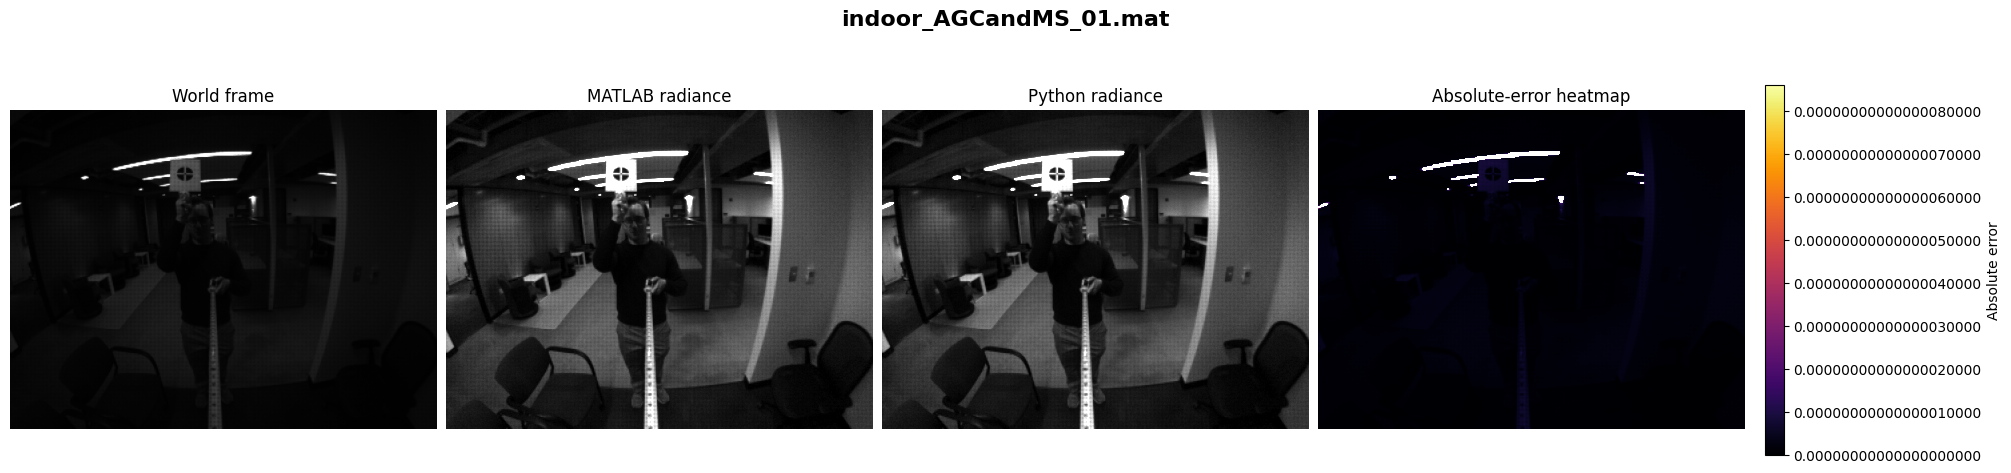

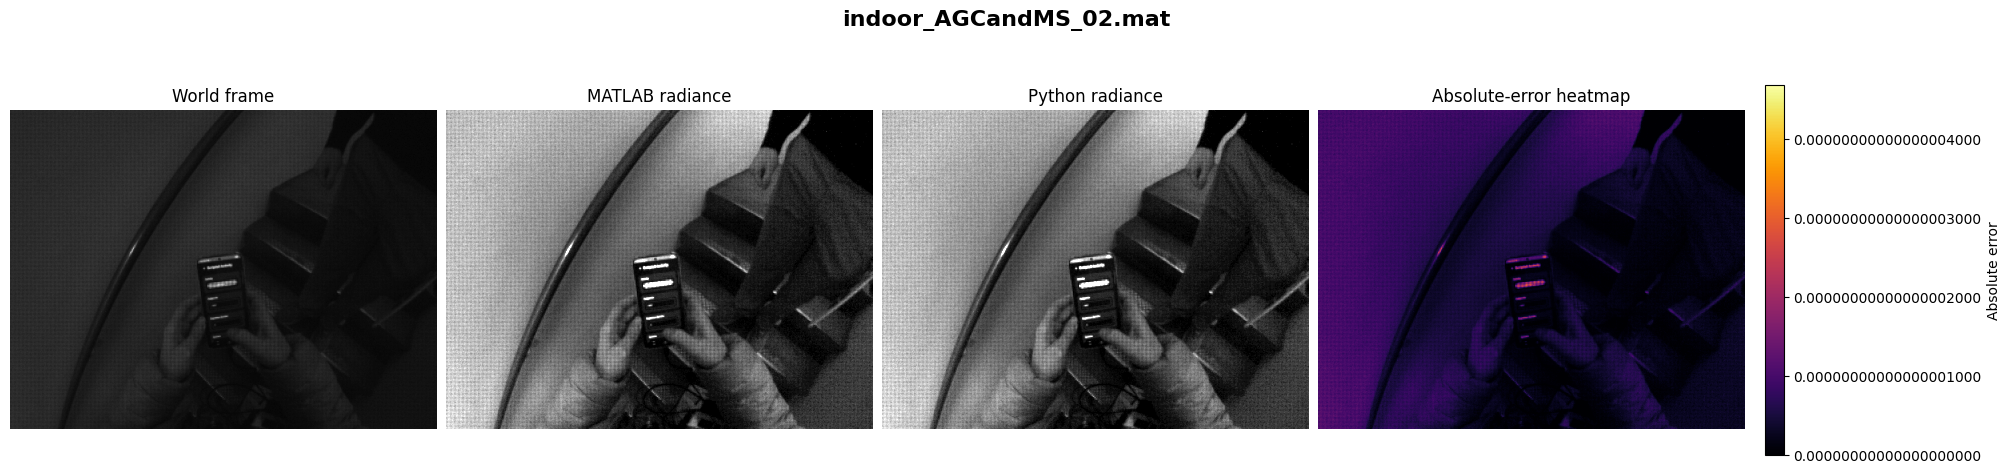

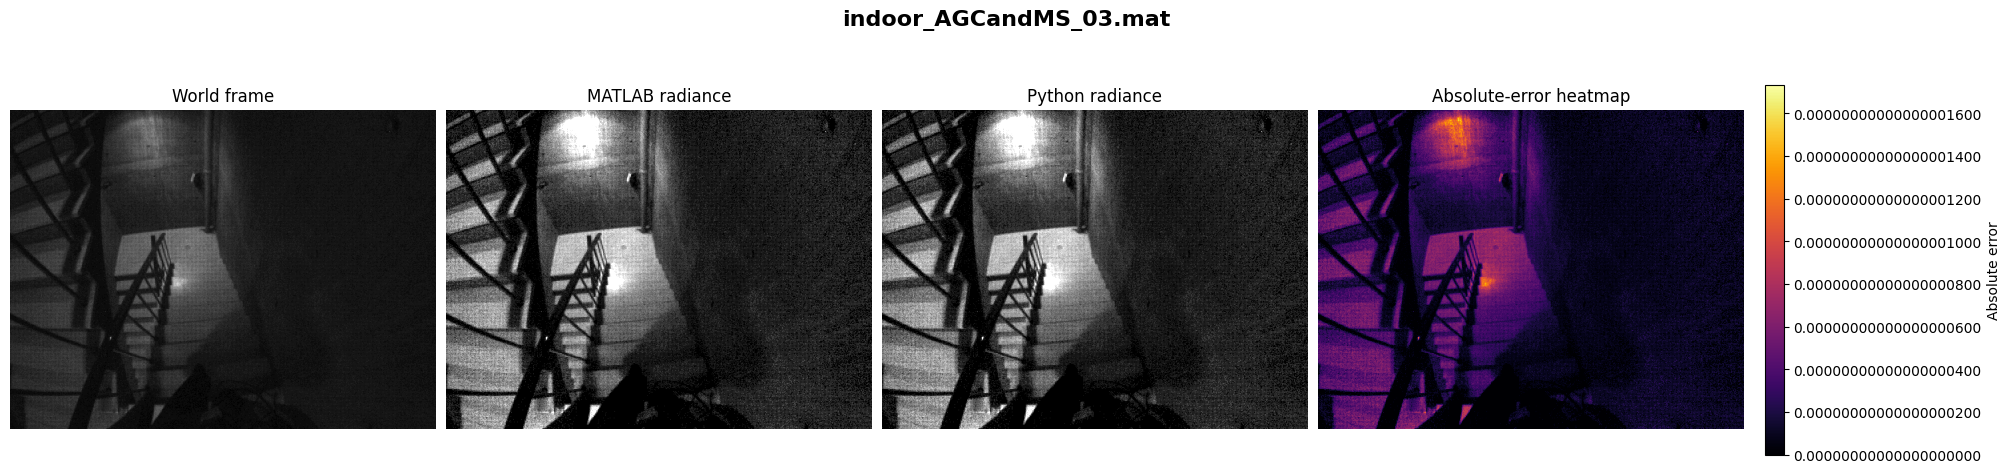

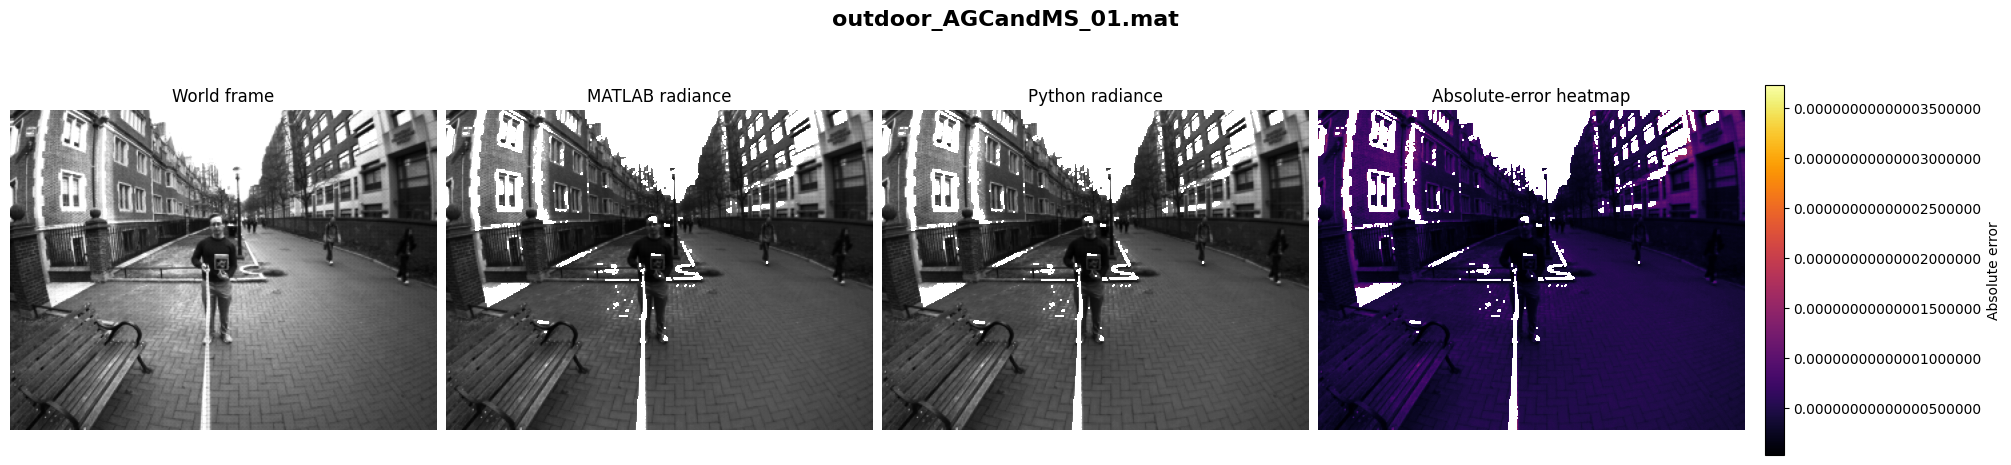

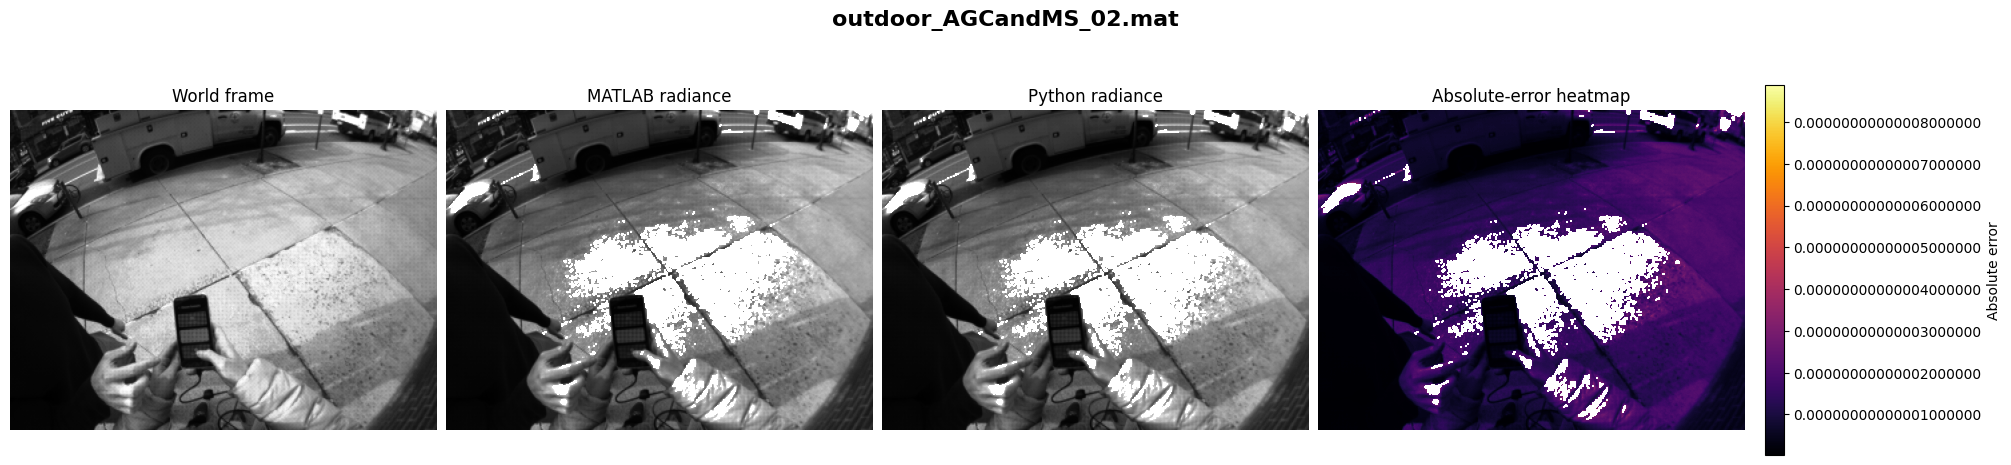

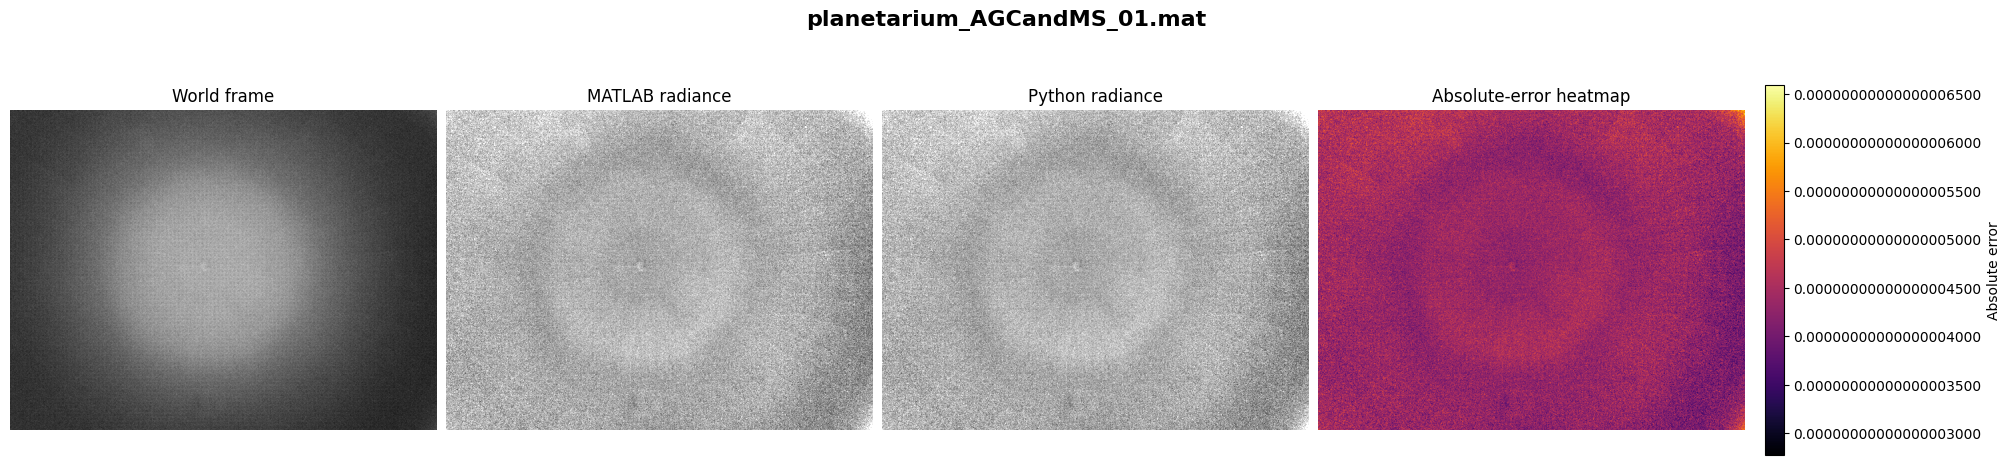

In [6]:
from matplotlib.ticker import FuncFormatter

# Create one 1-by-4 comparison figure for every measurement.
for measurement_path in measurement_paths:
    measurement_name: str = measurement_path.name
    output: dict[str, np.ndarray] = comparison_outputs[measurement_name]

    world_frame: np.ndarray = output["world_frame"]
    matlab_radiance: np.ndarray = output["matlab_radiance"]
    python_radiance: np.ndarray = output["python_radiance"]
    absolute_error: np.ndarray = output["absolute_error"]

    # Use the same display range for both radiance images so their brightness
    # and contrast can be compared directly. Ignore Inf and NaN when finding it.
    finite_radiance_values: np.ndarray = np.concatenate([
        matlab_radiance[np.isfinite(matlab_radiance)],
        python_radiance[np.isfinite(python_radiance)],
    ])
    radiance_min: float = float(np.min(finite_radiance_values))
    radiance_max: float = float(np.percentile(finite_radiance_values, 99))

    fig, axes = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)
    fig.suptitle(measurement_name, fontsize=16, fontweight="bold")

    axes[0].imshow(world_frame, cmap="gray")
    axes[0].set_title("World frame")

    axes[1].imshow(
        np.ma.masked_invalid(matlab_radiance),
        cmap="gray",
        vmin=radiance_min,
        vmax=radiance_max,
    )
    axes[1].set_title("MATLAB radiance")

    axes[2].imshow(
        np.ma.masked_invalid(python_radiance),
        cmap="gray",
        vmin=radiance_min,
        vmax=radiance_max,
    )
    axes[2].set_title("Python radiance")

    # Display the absolute MATLAB-versus-Python difference as a heatmap.
    error_heatmap = axes[3].imshow(
        np.ma.masked_invalid(absolute_error), cmap="inferno"
    )
    axes[3].set_title("Absolute-error heatmap")
    error_colorbar = fig.colorbar(error_heatmap, ax=axes[3], shrink=0.8)
    error_colorbar.set_label("Absolute error")
    error_colorbar.ax.yaxis.set_major_formatter(
        FuncFormatter(lambda value, position: f"{value:.20f}")
    )

    for axis in axes:
        axis.axis("off")

    plt.show()